# 00 — Systematic city selection from Köppen-Geiger zones

Produces `data/city_selection.csv` — the source of truth for all downstream analysis.

**Method:**
1. Download the GHS Urban Centre Database (GHSL-UCDB R2019A, ~13,000 urban centres globally)
2. Parse the built-in `E_KG_NM_LST` column — each row already carries the KG zone classification derived from the urban centre footprint (more appropriate than sampling at a single centroid point)
3. Filter to heat-relevant zones and cities with population ≥ 500,000
4. Apply stratified sampling: **3 cities per zone**, max 1 per country, continent diversity preferred
5. Merge with the three existing Brazilian cities (already in the analysis pipeline)
6. Output candidate table and map for manual review before proceeding

**Output:** `data/city_selection.csv`

**References:**
- Florczyk et al. (2019) GHS Urban Centre Database 2015 (UCDB R2019A). *JRC Data Catalogue*.
- Beck et al. (2018) Present and future Köppen-Geiger climate classification maps at 1-km resolution. *Scientific Data* 5, 180214. (Beck raster optionally used for validation only)


## Setup and data download

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from shapely.geometry import Point

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

N_PER_ZONE   = 3       # cities to select per KG zone
POP_MIN      = 500_000 # minimum urban centre population
MAX_PER_CTRY = 1       # max cities per country per zone

# ---- File paths -------------------------------------------------------------
KG_PATH   = DATA_DIR / 'koppen_geiger_1km_present.tif'
UCDB_PATH = DATA_DIR / 'GHS_UCDB_2015_R2019A.gpkg'
OUT_CSV   = DATA_DIR / 'city_selection.csv'

print('Paths set. DATA_DIR:', DATA_DIR.resolve())

Paths set. DATA_DIR: /Users/martynclark/heatInsights-notebooks/heat_threshold_analysis/data


In [2]:

# ---- Download Beck et al. (2018) KG raster ----------------------------------
# Figshare article 6396959 contains a single zip (Beck_KG_V1.zip, ~71 MB)
# that holds the present-day and future GeoTIFFs.
KG_ZIP_URL  = 'https://ndownloader.figshare.com/files/12407516'
KG_ZIP_PATH = DATA_DIR / 'Beck_KG_V1.zip'
KG_PRESENT_NAME = 'Beck_KG_V1_present_0p0083.tif'   # filename inside zip

if not KG_PATH.exists():
    if not KG_ZIP_PATH.exists():
        print('Downloading Beck et al. KG zip (~71 MB) …')
        try:
            with requests.get(KG_ZIP_URL, stream=True, timeout=300) as r:
                r.raise_for_status()
                total = int(r.headers.get('content-length', 0))
                downloaded = 0
                with open(KG_ZIP_PATH, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total:
                            print(f'  {downloaded/1e6:.0f} / {total/1e6:.0f} MB', end='\r')
            print(f'\nSaved zip: {KG_ZIP_PATH}  ({KG_ZIP_PATH.stat().st_size/1e6:.1f} MB)')
        except Exception as e:
            print(f'Download failed: {e}')
            print('Manual: https://figshare.com/articles/dataset/6396959')
            print(f'Download Beck_KG_V1.zip and save as: {KG_ZIP_PATH}')

    if KG_ZIP_PATH.exists() and KG_ZIP_PATH.stat().st_size > 1000:
        print(f'Extracting {KG_PRESENT_NAME} from zip …')
        with zipfile.ZipFile(KG_ZIP_PATH) as zf:
            names = zf.namelist()
            print(f'  Files in zip: {names}')
            match = next((n for n in names if KG_PRESENT_NAME in n), None)
            if match is None:
                # Try to find any present-day tif
                match = next((n for n in names if 'present' in n.lower() and n.endswith('.tif')), None)
            if match:
                data = zf.read(match)
                KG_PATH.write_bytes(data)
                print(f'Extracted: {KG_PATH}  ({KG_PATH.stat().st_size/1e6:.1f} MB)')
            else:
                print(f'Could not find present-day tif in zip. Contents: {names}')
else:
    print(f'KG raster found: {KG_PATH}  ({KG_PATH.stat().st_size/1e6:.1f} MB)')

# ---- Download GHSL-UCDB R2019A ----------------------------------------------
UCDB_URL = (
    'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/'
    'GHS_STAT_UCDB2015MT_GLOBE_R2019A/V1-2/'
    'GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2.zip'
)

if not UCDB_PATH.exists():
    print('\nDownloading GHSL-UCDB (~70 MB) …')
    try:
        with requests.get(UCDB_URL, stream=True, timeout=300) as r:
            r.raise_for_status()
            content = b''.join(r.iter_content(chunk_size=1024 * 1024))
        with zipfile.ZipFile(io.BytesIO(content)) as zf:
            print(f'  Files in zip: {zf.namelist()[:8]}')
            gpkg = next((n for n in zf.namelist() if n.lower().endswith('.gpkg')), None)
            shp  = next((n for n in zf.namelist() if n.lower().endswith('.shp')),  None)
            src_name = gpkg or shp
            if src_name:
                if gpkg:
                    KG_PATH.parent.joinpath(Path(src_name).name)   # reuse DATA_DIR
                    extracted = DATA_DIR / Path(src_name).name
                    extracted.write_bytes(zf.read(src_name))
                    extracted.rename(UCDB_PATH)
                else:
                    # shp needs companion files — extract all
                    zf.extractall(DATA_DIR)
                    extracted_shp = DATA_DIR / Path(src_name).name
                    extracted_shp.rename(UCDB_PATH.with_suffix('.shp'))
                    UCDB_PATH_USE = UCDB_PATH.with_suffix('.shp')
                print(f'Saved: {UCDB_PATH}')
            else:
                zf.extractall(DATA_DIR)
                print(f'Extracted to {DATA_DIR} — update UCDB_PATH if needed')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Manual: https://human-settlement.emergency.copernicus.eu/ghs_ucdb_2019.php')
        print(f'Extract GeoPackage and save as: {UCDB_PATH}')
else:
    print(f'UCDB found: {UCDB_PATH}  ({UCDB_PATH.stat().st_size/1e6:.1f} MB)')


KG raster found: data/koppen_geiger_1km_present.tif  (23.1 MB)
UCDB found: data/GHS_UCDB_2015_R2019A.gpkg  (27.2 MB)


## Load and inspect GHSL-UCDB

In [3]:
ucdb = gpd.read_file(UCDB_PATH)
print(f'UCDB loaded: {len(ucdb):,} urban centres')
print(f'CRS: {ucdb.crs}')
print(f'Columns: {list(ucdb.columns)}')

UCDB loaded: 13,135 urban centres
CRS: EPSG:4326
Columns: ['ID_HDC_G0', 'QA2_1V', 'AREA', 'BBX_LATMN', 'BBX_LONMN', 'BBX_LATMX', 'BBX_LONMX', 'GCPNT_LAT', 'GCPNT_LON', 'CTR_MN_NM', 'CTR_MN_ISO', 'XBRDR', 'XCTR_NBR', 'XC_NM_LST', 'XC_ISO_LST', 'GRGN_L1', 'GRGN_L2', 'UC_NM_MN', 'UC_NM_LST', 'UC_NM_SRC', 'H75_NBR', 'H90_NBR', 'H00_NBR', 'H75_AREA', 'H90_AREA', 'H00_AREA', 'E_BM_NM_LST', 'E_SL_LST', 'EL_AV_ALS', 'E_KG_NM_LST', 'E_RB_NM_LST', 'E_WR_P_90', 'E_WR_P_00', 'E_WR_P_14', 'E_WR_T_90', 'E_WR_T_00', 'E_WR_T_14', 'B75', 'B90', 'B00', 'B15', 'P75', 'P90', 'P00', 'P15', 'BUCAP75', 'BUCAP90', 'BUCAP00', 'BUCAP15', 'NTL_AV', 'GDP90_SM', 'GDP00_SM', 'GDP15_SM', 'INCM_CMI', 'DEV_CMI', 'TT2CC', 'E_GR_AV90', 'E_GR_AV00', 'E_GR_AV14', 'E_GR_AH90', 'E_GR_AM90', 'E_GR_AL90', 'E_GR_AT90', 'E_GR_AH00', 'E_GR_AM00', 'E_GR_AL00', 'E_GR_AT00', 'E_GR_AH14', 'E_GR_AM14', 'E_GR_AL14', 'E_GR_AT14', 'E_EC2E_E75', 'E_EC2E_E90', 'E_EC2E_E00', 'E_EC2E_E15', 'E_EC2E_R75', 'E_EC2E_R90', 'E_EC2E_R00', 'E_EC2E_R

In [4]:
# ---- Normalise column names -------------------------------------------------
col_map = {
    'UC_NM_MN':  'city_name',       # main name (may include agglomeration list)
    'UC_NM_LST': 'city_name_list',  # keep separate — do NOT map both to city_name
    'CTR_MN_NM': 'country_name',
    'CTR_MN_ISO':'country_iso',
    'P15':       'population',
    'P_2015':    'population',
    'POP2015':   'population',
    'GCPNT_LAT': 'lat',
    'GCPNT_LON': 'lon',
    'MEAN_LAT':  'lat',
    'MEAN_LON':  'lon',
}
ucdb = ucdb.rename(columns={k: v for k, v in col_map.items() if k in ucdb.columns})

if 'lat' not in ucdb.columns or 'lon' not in ucdb.columns:
    if ucdb.crs and ucdb.crs.to_epsg() != 4326:
        ucdb = ucdb.to_crs('EPSG:4326')
    ucdb['lon'] = ucdb.geometry.centroid.x
    ucdb['lat'] = ucdb.geometry.centroid.y

ucdb['population'] = pd.to_numeric(ucdb['population'], errors='coerce')

# Primary name: first token before ';' — avoids "Jakarta; Bekasi; Tangerang…" IDs
ucdb['city_primary'] = ucdb['city_name'].str.split(';').str[0].str.strip()

# ---- Continent from UCDB's built-in GRGN_L1 / GRGN_L2 ----------------------
GRGN_L2_TO_CONTINENT = {
    'Northern America':                'North America',
    'Latin America and the Caribbean': 'South America',
    'Caribbean':                       'South America',
    'Central America':                 'South America',
    'South America':                   'South America',
}

def _continent_from_grgn(row):
    l2 = str(row.get('GRGN_L2', '') or '')
    l1 = str(row.get('GRGN_L1', '') or '')
    if l2 in GRGN_L2_TO_CONTINENT:
        return GRGN_L2_TO_CONTINENT[l2]
    if l1 in ('Africa', 'Asia', 'Europe', 'Oceania'):
        return l1
    return 'Unknown'

if 'GRGN_L1' in ucdb.columns:
    ucdb['continent'] = ucdb.apply(_continent_from_grgn, axis=1)
else:
    ucdb['continent'] = 'Unknown'

print('Required columns present:', [c for c in ['city_primary','city_name','country_iso','population','lat','lon','continent'] if c in ucdb.columns])
print(f'Population range: {ucdb["population"].min():,.0f} – {ucdb["population"].max():,.0f}')
print(f'Cities with population ≥ {POP_MIN:,}: {(ucdb["population"] >= POP_MIN).sum():,}')
print(f'\nContinent distribution (all UCDB):')
print(ucdb['continent'].value_counts().to_string())


Required columns present: ['city_primary', 'city_name', 'country_iso', 'population', 'lat', 'lon', 'continent']
Population range: 50,002 – 40,589,878
Cities with population ≥ 500,000: 996

Continent distribution (all UCDB):
continent
Asia             7737
Africa           2805
South America    1076
Europe           1059
North America     372
Oceania            86


## Assign Köppen-Geiger zone from UCDB built-in classification

In [5]:
# ---- Map UCDB verbose KG descriptions → standard 2-3 letter codes ----------
KG_VERBOSE_TO_CODE = {
    'Tropical rain forest':                                    'Af',
    'Tropical monsoon':                                        'Am',
    'Tropical savannah with dry summer':                       'As',
    'Tropical savannah with dry winter':                       'Aw',
    'Desert (arid), and  Hot arid':                            'BWh',
    'Desert (arid), and  Cold arid':                           'BWk',
    'Steppe (semi-arid), and  Hot arid':                       'BSh',
    'Steppe (semi-arid), and  Cold arid':                      'BSk',
    'Mild temperate with dry summer, and  Hot summer':         'Csa',
    'Mild temperate with dry summer, and  Warm summer':        'Csb',
    'Mild temperate with dry summer, and  Cool summer':        'Csc',
    'Mild temperate with dry winter, and  Hot summer':         'Cwa',
    'Mild temperate with dry winter, and  Warm summer':        'Cwb',
    'Mild temperate with dry winter, and  Cool summer':        'Cwc',
    'Mild temperate, fully humid, and  Hot summer':            'Cfa',
    'Mild temperate, fully humid, and  Warm summer':           'Cfb',
    'Mild temperate, fully humid, and  Cool summer':           'Cfc',
    'Snow with dry summer, and  Hot summer':                   'Dsa',
    'Snow with dry summer, and  Warm summer':                  'Dsb',
    'Snow with dry summer, and  Cool summer':                  'Dsc',
    'Snow with dry summer, and  Extremely cold winter':        'Dsd',
    'Snow with dry winter, and  Hot summer':                   'Dwa',
    'Snow with dry winter, and  Warm summer':                  'Dwb',
    'Snow with dry winter, and  Cool summer':                  'Dwc',
    'Snow with dry winter, and  Extremely cold winter':        'Dwd',
    'Snow, fully humid, and  Hot summer':                      'Dfa',
    'Snow, fully humid, and  Warm summer':                     'Dfb',
    'Snow, fully humid, and  Cool summer':                     'Dfc',
    'Snow, fully humid, and  Extremely cold winter':           'Dfd',
    'Polar tundra':                                            'ET',
    'Polar frost':                                             'EF',
}

HEAT_ZONES = {
    'Af', 'Am', 'Aw',
    'BWh', 'BWk', 'BSh', 'BSk',
    'Cwa', 'Cwb',
    'Csa', 'Csb',
    'Cfa', 'Cfb',
    'Dfa', 'Dfb', 'Dwa', 'Dwb',
}

def parse_kg_zone(raw):
    if pd.isna(raw) or str(raw).strip() == '':
        return 'Unknown'
    primary = str(raw).split(';')[0].strip()
    return KG_VERBOSE_TO_CODE.get(primary, 'Unknown')

ucdb['kg_zone']  = ucdb['E_KG_NM_LST'].apply(parse_kg_zone)
ucdb['kg_class'] = ucdb['kg_zone'].str[0]
ucdb['heat_relevant'] = ucdb['kg_zone'].isin(HEAT_ZONES)

# ---- Filter out mega-agglomerations using UCDB bounding box columns ---------
# Urban centres whose spatial footprint exceeds MAX_BBOX_DEG in either dimension
# span multiple distinct cities (e.g. Jakarta–Bogor–Cianjur corridor ~200 km).
# These are scientifically inappropriate for single-city neighbourhood CV analysis
# and technically too large for GEE getRegion at 1 km resolution.
MAX_BBOX_DEG = 1.5   # ~165 km at equator

bbx_cols = {'BBX_LATMN': 'bbx_latmn', 'BBX_LATMX': 'bbx_latmx',
            'BBX_LONMN': 'bbx_lonmn', 'BBX_LONMX': 'bbx_lonmx'}
ucdb = ucdb.rename(columns={k: v for k, v in bbx_cols.items() if k in ucdb.columns})

if 'bbx_latmn' in ucdb.columns:
    ucdb['bbox_width']  = ucdb['bbx_lonmx'] - ucdb['bbx_lonmn']
    ucdb['bbox_height'] = ucdb['bbx_latmx'] - ucdb['bbx_latmn']
    n_before = len(ucdb)
    ucdb = ucdb[(ucdb['bbox_width']  <= MAX_BBOX_DEG) |
                (ucdb['bbox_height'] <= MAX_BBOX_DEG)]
    print(f'Removed {n_before - len(ucdb):,} mega-agglomeration urban centres '
          f'(bbox > {MAX_BBOX_DEG}° in both dimensions)')
else:
    print('BBX columns not found — skipping agglomeration filter')

cities = ucdb[ucdb['population'] >= POP_MIN].copy().reset_index(drop=True)
print(f'Cities with population ≥ {POP_MIN:,} after agglomeration filter: {len(cities):,}')

unknown = ucdb.loc[ucdb['kg_zone'] == 'Unknown', 'E_KG_NM_LST'].dropna().unique()
if len(unknown):
    print(f'\nUnmapped E_KG_NM_LST values ({len(unknown)}):')
    for v in sorted(unknown)[:10]:
        print(f'  {repr(v)}')

print(f'\nKG zone distribution (top 15):')
print(cities['kg_zone'].value_counts().head(15).to_string())
print(f'\nHeat-relevant cities: {cities["heat_relevant"].sum():,}')


Removed 0 mega-agglomeration urban centres (bbox > 1.5° in both dimensions)
Cities with population ≥ 500,000 after agglomeration filter: 996

Unmapped E_KG_NM_LST values (2):
  'NAN'
  'Tundra'

KG zone distribution (top 15):
kg_zone
Aw     155
Cwa    138
Cfa    137
BSh     88
BWh     73
Am      68
Csa     67
BSk     59
Cfb     55
Af      40
Dfb     34
Dwa     23
Cwb     14
Dfa     13
As      13

Heat-relevant cities: 979


## Stratified sampling: 3 cities per zone

In [6]:

# ---- Existing cities (already in analysis pipeline) -------------------------
EXISTING = pd.DataFrame([
    {'city_id': 'salvador',  'city_primary': 'Salvador',  'city_name': 'Salvador',
     'country_iso': 'BRA', 'country_name': 'Brazil', 'continent': 'South America',
     'kg_zone': 'Aw', 'kg_class': 'A', 'population': 2900000,
     'lat': -12.97, 'lon': -38.51, 'existing': True, 'selection_note': 'existing pilot city'},
    {'city_id': 'teresina',  'city_primary': 'Teresina',  'city_name': 'Teresina',
     'country_iso': 'BRA', 'country_name': 'Brazil', 'continent': 'South America',
     'kg_zone': 'Aw', 'kg_class': 'A', 'population': 900000,
     'lat': -5.09,  'lon': -42.80, 'existing': True, 'selection_note': 'existing pilot city'},
    {'city_id': 'caceres',   'city_primary': 'Cáceres',   'city_name': 'Cáceres',
     'country_iso': 'BRA', 'country_name': 'Brazil', 'continent': 'South America',
     'kg_zone': 'Aw', 'kg_class': 'A', 'population': 100000,
     'lat': -16.07, 'lon': -57.68, 'existing': True, 'selection_note': 'existing pilot city'},
])

# ---- Sampling algorithm -----------------------------------------------------
def sample_zone(group, n, max_per_country, existing_countries):
    selected = []
    used_countries  = set(existing_countries)
    continent_count = {}

    candidates = group.sort_values('population', ascending=False)

    for _, row in candidates.iterrows():
        if len(selected) >= n:
            break
        iso  = row.get('country_iso', '')
        cont = row.get('continent', 'Unknown')
        if iso in used_countries:
            continue
        if continent_count.get(cont, 0) >= 2:
            continue
        selected.append(row.to_dict())
        used_countries.add(iso)
        continent_count[cont] = continent_count.get(cont, 0) + 1

    if len(selected) < n:
        for _, row in candidates.iterrows():
            if len(selected) >= n:
                break
            iso = row.get('country_iso', '')
            if iso in used_countries:
                continue
            selected.append(row.to_dict())
            used_countries.add(iso)

    result = pd.DataFrame(selected)
    if not result.empty:
        result['existing']       = False
        result['selection_note'] = 'auto-selected: pop rank within zone'
    return result


# ---- Run sampling -----------------------------------------------------------
heat_cities = cities[cities['heat_relevant']].copy()

sampled_parts = [EXISTING]

for zone, group in heat_cities.groupby('kg_zone'):
    existing_in_zone   = EXISTING[EXISTING['kg_zone'] == zone]
    existing_countries = set(existing_in_zone['country_iso'].tolist())
    slots_remaining    = max(0, N_PER_ZONE - len(existing_in_zone))

    if slots_remaining == 0:
        continue

    selected = sample_zone(group, slots_remaining, MAX_PER_CTRY, existing_countries)
    if not selected.empty:
        sampled_parts.append(selected)

selected_all = pd.concat(sampled_parts, ignore_index=True)

# ---- Generate city_id from primary name + country ISO -----------------------
def make_city_id(row):
    if row.get('existing', False) and pd.notna(row.get('city_id', None)):
        return row['city_id']
    name = str(row.get('city_primary', row.get('city_name', 'unknown'))).lower()
    for ch in " -'\".,();[]":
        name = name.replace(ch, '_')
    name = name.strip('_')
    iso = str(row.get('country_iso', 'XX')).lower()
    return f"{name}_{iso}"

if 'city_id' not in selected_all.columns:
    selected_all['city_id'] = None
mask = selected_all['city_id'].isna() | (selected_all['city_id'] == '')
selected_all.loc[mask, 'city_id'] = selected_all[mask].apply(make_city_id, axis=1)

print(f'Total cities selected: {len(selected_all)}')
print(f'Zones covered:         {selected_all["kg_zone"].nunique()}')
print(f'Countries covered:     {selected_all["country_iso"].nunique()}')
print(f'Continents covered:    {selected_all["continent"].nunique()}')
print(f'\nContinent breakdown:')
print(selected_all['continent'].value_counts().to_string())


Total cities selected: 49
Zones covered:         17
Countries covered:     33
Continents covered:    5

Continent breakdown:
continent
Asia             22
South America    10
Europe            7
Africa            5
North America     5


In [7]:
# ---- Summary table ----------------------------------------------------------
display_cols = ['city_id', 'city_name', 'country_iso', 'continent',
                'kg_zone', 'kg_class', 'population', 'lat', 'lon',
                'existing', 'selection_note']
display_cols = [c for c in display_cols if c in selected_all.columns]

summary = (
    selected_all[display_cols]
    .sort_values(['kg_class', 'kg_zone', 'population'], ascending=[True, True, False])
    .reset_index(drop=True)
)

# Count per zone
zone_counts = summary.groupby('kg_zone').size().reset_index(name='n_selected')
zones_short = zone_counts[zone_counts['n_selected'] < N_PER_ZONE]

display(
    summary.style
    .set_caption(f'Selected cities — {len(summary)} total across {summary["kg_zone"].nunique()} zones')
    .format({'population': '{:,.0f}', 'lat': '{:.2f}', 'lon': '{:.2f}'})
    .apply(lambda s: ['background-color: #fff3cd' if v else '' for v in summary['existing']], axis=0)
)

print(f'\nZones with fewer than {N_PER_ZONE} cities (population constraint):')
if len(zones_short) > 0:
    print(zones_short.to_string(index=False))
else:
    print('  None — all zones at target count')

,city_id,city_name,country_iso,continent,kg_zone,kg_class,population,lat,lon,existing,selection_note
0,jakarta_idn,Jakarta,IDN,Asia,Af,A,"36,312,539",-6.38,106.85,False,auto-selected: pop rank within zone
1,singapore_sgp,Singapore,SGP,Asia,Af,A,"6,920,918",1.39,103.89,False,auto-selected: pop rank within zone
2,kampala_uga,Kampala,UGA,Africa,Af,A,"3,483,365",0.33,32.58,False,auto-selected: pop rank within zone
3,mumbai_ind,Mumbai,IND,Asia,Am,A,"21,755,882",19.14,72.97,False,auto-selected: pop rank within zone
4,quezon_city__manila_phl,Quezon City [Manila],PHL,Asia,Am,A,"21,691,141",14.55,121.02,False,auto-selected: pop rank within zone
5,miami_usa,Miami,USA,North America,Am,A,"5,406,570",26.18,-80.21,False,auto-selected: pop rank within zone
6,salvador,Salvador,BRA,South America,Aw,A,"2,900,000",-12.97,-38.51,True,existing pilot city
7,teresina,Teresina,BRA,South America,Aw,A,"900,000",-5.09,-42.80,True,existing pilot city
8,caceres,Cáceres,BRA,South America,Aw,A,"100,000",-16.07,-57.68,True,existing pilot city
9,delhi__new_delhi_ind,Delhi [New Delhi],IND,Asia,BSh,B,"26,658,714",28.63,77.20,False,auto-selected: pop rank within zone



Zones with fewer than 3 cities (population constraint):
kg_zone  n_selected
    Dwa           2
    Dwb           2


## World map of selected cities

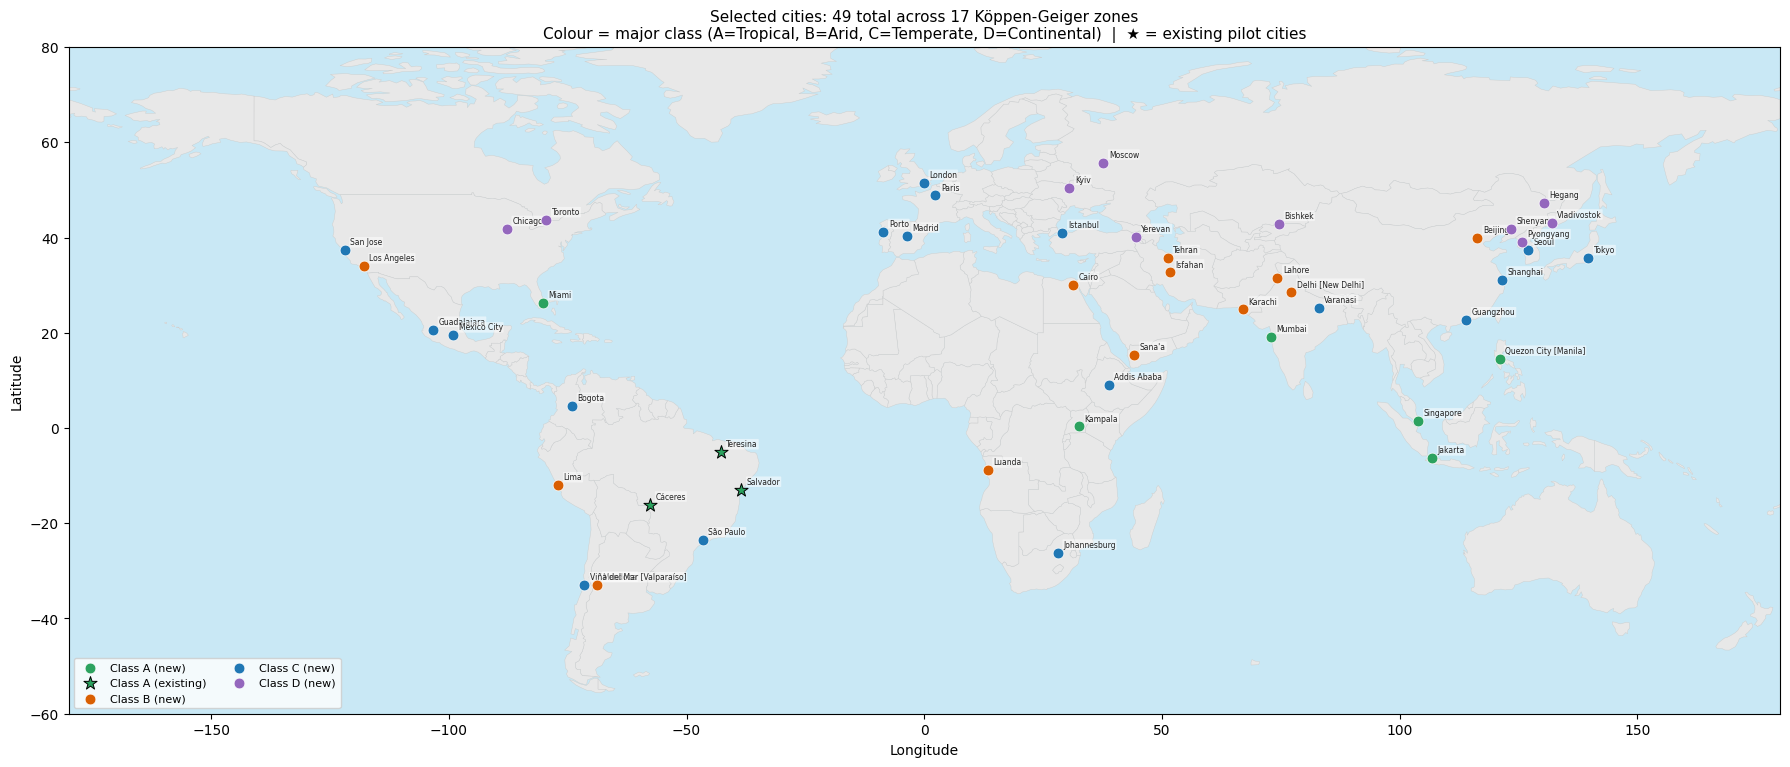

In [8]:
from matplotlib.cm import get_cmap

# ---- KG class colour palette ------------------------------------------------
CLASS_COLORS = {'A': '#2ca25f', 'B': '#d95f02', 'C': '#1f77b4', 'D': '#9467bd'}

# ---- World basemap: Natural Earth 110m countries (cached locally) -----------
NE_PATH = DATA_DIR / 'ne_110m_admin_0_countries.zip'
NE_URL  = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

if not NE_PATH.exists():
    print('Downloading Natural Earth 110m countries (~500 KB) …')
    with requests.get(NE_URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        NE_PATH.write_bytes(r.content)
    print(f'Saved: {NE_PATH}')

world = gpd.read_file(NE_PATH)

fig, ax = plt.subplots(figsize=(18, 9))
world.plot(ax=ax, color='#e8e8e8', edgecolor='#cccccc', linewidth=0.3)
ax.set_facecolor('#c9e8f5')

for cls, grp in summary.groupby('kg_class'):
    color = CLASS_COLORS.get(cls, '#888888')
    existing_mask = grp.get('existing', pd.Series([False]*len(grp), index=grp.index))
    new = grp[~existing_mask.fillna(False)]
    if len(new):
        ax.scatter(new['lon'], new['lat'], c=color, s=60,
                   zorder=5, edgecolor='white', linewidth=0.5,
                   label=f'Class {cls} (new)')
    ex = grp[existing_mask.fillna(False)]
    if len(ex):
        ax.scatter(ex['lon'], ex['lat'], c=color, s=100, marker='*',
                   zorder=6, edgecolor='black', linewidth=0.7,
                   label=f'Class {cls} (existing)')

for _, row in summary.iterrows():
    ax.annotate(
        row.get('city_name', row.get('city_id', '')),
        xy=(row['lon'], row['lat']),
        xytext=(4, 4), textcoords='offset points',
        fontsize=5.5, color='#222222',
        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, lw=0),
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_title(
    f'Selected cities: {len(summary)} total across {summary["kg_zone"].nunique()} Köppen-Geiger zones\n'
    f'Colour = major class (A=Tropical, B=Arid, C=Temperate, D=Continental)  |  ★ = existing pilot cities',
    fontsize=11,
)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Zone coverage summary

In [9]:
# ---- Per-zone counts and notes ----------------------------------------------
zone_summary = (
    summary.groupby(['kg_class', 'kg_zone'])
    .agg(
        n_cities=('city_name', 'count'),
        n_countries=('country_iso', 'nunique'),
        continents=('continent', lambda x: ', '.join(sorted(x.unique()))),
        cities=('city_name', lambda x: ', '.join(x.astype(str))),
        max_pop=('population', 'max'),
    )
    .reset_index()
    .sort_values(['kg_class', 'kg_zone'])
)

display(
    zone_summary.style
    .format({'max_pop': '{:,.0f}'})
    .apply(
        lambda s: ['background-color: #ffeeba' if v < N_PER_ZONE else '' for v in zone_summary['n_cities']],
        axis=0,
    )
    .set_caption(
        f'Zone coverage — yellow = fewer than {N_PER_ZONE} cities (population constraint)'
    )
)

print(f'\nTotal heat-relevant zones in HEAT_ZONES list: {len(HEAT_ZONES)}')
print(f'Zones with at least 1 city selected: {zone_summary["n_cities"].gt(0).sum()}')
print(f'Zones at target ({N_PER_ZONE} cities): {zone_summary["n_cities"].eq(N_PER_ZONE).sum()}')

,kg_class,kg_zone,n_cities,n_countries,continents,cities,max_pop
0,A,Af,3,3,"Africa, Asia","Jakarta, Singapore, Kampala","36,312,539"
1,A,Am,3,3,"Asia, North America","Mumbai, Quezon City [Manila], Miami","21,755,882"
2,A,Aw,3,1,South America,"Salvador, Teresina, Cáceres","2,900,000"
3,B,BSh,3,3,"Africa, Asia","Delhi [New Delhi], Lahore, Luanda","26,658,714"
4,B,BSk,3,3,"Asia, North America","Beijing, Los Angeles, Tehran","17,982,668"
5,B,BWh,3,3,"Africa, Asia, South America","Cairo, Karachi, Lima","19,734,086"
6,B,BWk,3,3,"Asia, South America","Sana'a, Isfahan, Mendoza","2,537,060"
7,C,Cfa,3,3,"Asia, South America","Tokyo, Shanghai, São Paulo","33,028,731"
8,C,Cfb,3,3,"Europe, South America","Paris, London, Bogota","9,711,652"
9,C,Csa,3,3,"Asia, Europe","Istanbul, Madrid, Varanasi","14,111,242"



Total heat-relevant zones in HEAT_ZONES list: 17
Zones with at least 1 city selected: 17
Zones at target (3 cities): 15


## Manual adjustments

Review the table and map above. Common reasons to override the automatic selection:
- A selected city has poor GSHTD data coverage (check in Phase 2)
- A scientifically important city was excluded (wrong KG zone assignment at centroid, or population just below threshold)
- Geographic clustering: two cities in same zone are very close to each other

To swap a city: add a row to `MANUAL_SWAPS` below with the city to remove and the replacement.
Leave empty to accept the automatic selection.

In [10]:
# ---- Manual overrides (edit as needed) --------------------------------------
# Format: {'remove_city_id': 'xxx', 'add': {city dict}}
# Leave MANUAL_SWAPS = [] to accept automatic selection
MANUAL_SWAPS = []

for swap in MANUAL_SWAPS:
    remove_id = swap.get('remove_city_id')
    add_row   = swap.get('add', {})
    if remove_id:
        selected_all = selected_all[selected_all['city_id'] != remove_id]
        print(f'Removed: {remove_id}')
    if add_row:
        selected_all = pd.concat([selected_all, pd.DataFrame([add_row])], ignore_index=True)
        print(f'Added: {add_row.get("city_id", add_row.get("city_name", "?"))}')

if not MANUAL_SWAPS:
    print('No manual overrides — automatic selection accepted.')

No manual overrides — automatic selection accepted.


## Compute bounding boxes and export

In [11]:
# ---- Bounding boxes from UCDB footprint, capped at 0.75° half-width ---------
BBOX_CAP = 0.75

def _make_bbox(row):
    lat, lon = row['lat'], row['lon']
    if 'bbx_latmn' in row and pd.notna(row.get('bbx_latmn')):
        half_lat = min((row['bbx_latmx'] - row['bbx_latmn']) / 2, BBOX_CAP)
        half_lon = min((row['bbx_lonmx'] - row['bbx_lonmn']) / 2, BBOX_CAP)
    else:
        half_lat = half_lon = BBOX_CAP
    return pd.Series({
        'bbox_south': round(lat - half_lat, 4),
        'bbox_north': round(lat + half_lat, 4),
        'bbox_west':  round(lon - half_lon, 4),
        'bbox_east':  round(lon + half_lon, 4),
    })

final = selected_all.copy()
bbox_df = final.apply(_make_bbox, axis=1)
final = pd.concat([final, bbox_df], axis=1)

# ---- Compute pixel count and chunk days at 1 km resolution ------------------
DEG_PER_PX_1KM = 1 / 111          # degrees per pixel at 1 km
GEE_VALUE_LIMIT = 900_000
MIN_CHUNK_DAYS  = 7
MAX_CHUNK_DAYS  = 90

def _pixel_stats(row):
    w = row['bbox_east']  - row['bbox_west']
    h = row['bbox_north'] - row['bbox_south']
    n_px = int((w / DEG_PER_PX_1KM) * (h / DEG_PER_PX_1KM))
    n_px = max(n_px, 1)
    chunk = max(MIN_CHUNK_DAYS, min(MAX_CHUNK_DAYS, GEE_VALUE_LIMIT // n_px))
    n_chunks = int(np.ceil(18 * 365 / chunk))   # approximate for 18-year record
    return pd.Series({'n_pixels_1km': n_px, 'chunk_days_1km': chunk,
                      'n_chunks_1km': n_chunks})

pixel_df = final.apply(_pixel_stats, axis=1)
final = pd.concat([final, pixel_df], axis=1)

# ---- GSHTD GEE collection paths (verified) ----------------------------------
CONTINENT_TO_GEE = {
    'South America':  'projects/sat-io/open-datasets/global-daily-air-temp/latin_america',
    'North America':  'projects/sat-io/open-datasets/global-daily-air-temp/north_america',
    'Africa':         'projects/sat-io/open-datasets/global-daily-air-temp/africa',
    'Asia':           'projects/sat-io/open-datasets/global-daily-air-temp/europe_asia',
    'Europe':         'projects/sat-io/open-datasets/global-daily-air-temp/europe_asia',
    'Oceania':        'projects/sat-io/open-datasets/global-daily-air-temp/australia',
    'Unknown':        'TBC — verify GEE catalog',
}
final['gee_collection'] = final['continent'].map(CONTINENT_TO_GEE).fillna('TBC — verify GEE catalog')

# ---- Select and order output columns ----------------------------------------
out_cols = [
    'city_id', 'city_primary', 'city_name', 'country_name', 'country_iso', 'continent',
    'kg_zone', 'kg_class', 'population',
    'lat', 'lon',
    'bbox_west', 'bbox_east', 'bbox_south', 'bbox_north',
    'n_pixels_1km', 'chunk_days_1km', 'n_chunks_1km',
    'gee_collection', 'existing', 'selection_note',
]
out_cols = [c for c in out_cols if c in final.columns]
final_out = (
    final[out_cols]
    .sort_values(['kg_class', 'kg_zone', 'population'], ascending=[True, True, False])
    .reset_index(drop=True)
)

final_out.to_csv(OUT_CSV, index=False)
print(f'Saved: {OUT_CSV}  ({len(final_out)} cities)')

print(f'\nPixel count distribution at 1 km (post-bbox-cap):')
print(f'  Min  : {final_out["n_pixels_1km"].min():,}')
print(f'  Median: {final_out["n_pixels_1km"].median():,.0f}')
print(f'  Max  : {final_out["n_pixels_1km"].max():,}')

print(f'\nCities by chunk size (smaller = more GEE calls, but still feasible):')
bins = [0, 30, 60, 90]
labels = ['7–30 days (large bbox)', '31–60 days', '61–90 days']
final_out['chunk_bin'] = pd.cut(final_out['chunk_days_1km'], bins=bins, labels=labels)
print(final_out['chunk_bin'].value_counts().sort_index().to_string())

print(f'\nGEE collection assignments:')
print(final_out.groupby('gee_collection')['city_primary'].count().to_string())

print(f'\nPreview (sorted by pixel count):')
display(
    final_out[['city_id','city_primary','country_iso','kg_zone',
               'n_pixels_1km','chunk_days_1km','n_chunks_1km','gee_collection']]
    .sort_values('n_pixels_1km', ascending=False)
    .head(20)
)


Saved: data/city_selection.csv  (49 cities)

Pixel count distribution at 1 km (post-bbox-cap):
  Min  : 369
  Median: 4,014
  Max  : 27,722

Cities by chunk size (smaller = more GEE calls, but still feasible):
chunk_bin
7–30 days (large bbox)     0
31–60 days                 7
61–90 days                42

GEE collection assignments:
gee_collection
projects/sat-io/open-datasets/global-daily-air-temp/africa            5
projects/sat-io/open-datasets/global-daily-air-temp/europe_asia      29
projects/sat-io/open-datasets/global-daily-air-temp/latin_america    10
projects/sat-io/open-datasets/global-daily-air-temp/north_america     5

Preview (sorted by pixel count):


,city_id,city_primary,country_iso,kg_zone,n_pixels_1km,chunk_days_1km,n_chunks_1km,gee_collection
6,salvador,Salvador,BRA,Aw,27722,32,206,projects/sat-io/open-datasets/global-daily-air...
7,teresina,Teresina,BRA,Aw,27722,32,206,projects/sat-io/open-datasets/global-daily-air...
8,caceres,Cáceres,BRA,Aw,27722,32,206,projects/sat-io/open-datasets/global-daily-air...
0,jakarta_idn,Jakarta,IDN,Af,17794,50,132,projects/sat-io/open-datasets/global-daily-air...
13,los_angeles_usa,Los Angeles,USA,BSk,17324,51,129,projects/sat-io/open-datasets/global-daily-air...
33,guangzhou_chn,Guangzhou,CHN,Cwa,17274,52,127,projects/sat-io/open-datasets/global-daily-air...
21,tokyo_jpn,Tokyo,JPN,Cfa,15084,59,112,projects/sat-io/open-datasets/global-daily-air...
39,chicago_usa,Chicago,USA,Dfa,11964,75,88,projects/sat-io/open-datasets/global-daily-air...
43,toronto_can,Toronto,CAN,Dfb,10094,89,74,projects/sat-io/open-datasets/global-daily-air...
30,san_jose_usa,San Jose,USA,Csb,8494,90,73,projects/sat-io/open-datasets/global-daily-air...


## Next steps

Once `city_selection.csv` looks correct:

1. **Verify GSHTD GEE paths** — test a single extraction for one city from each continent to confirm the `gee_collection` paths are correct. Update the `CONTINENT_TO_GEE` dict above and re-export if any paths are wrong.

2. **Check bounding boxes** — cities at the edge of continents (coastal megacities) may need asymmetric bbox adjustments. Edit `MANUAL_SWAPS` or directly edit `city_selection.csv`.

3. **Proceed to `00b_data_acquisition_global.ipynb`** — iterates over `city_selection.csv` and runs GEE downloads for Tmax, Tmin, and population for each new city.

## GEE extraction for all cities

Reads `city_selection.csv` and downloads Tmax and Tmin from GSHTD for every city that
does not already have a cached `.nc` file.

**Parallelisation:** cities are independent — `ThreadPoolExecutor` submits all cities
concurrently. GEE throttles internally; `N_WORKERS=4` is safe for a standard quota.
Each city download is itself chunked into 90-day windows (matching the existing pipeline).

**Skipping:** any city whose `{city_id}_tmax.nc` and `{city_id}_tmin.nc` already exist
in `DATA_DIR` is skipped automatically. Set `FORCE_REFRESH=True` to re-download.

**After this cell:** verify outputs with the snippet at the bottom, then proceed to
`02_compute_baselines.ipynb` with the extended `CITY_KEYS` list.


In [ ]:
import ee
import shutil
import time
import threading
import xarray as xr
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Configuration ----------------------------------------------------------
GEE_PROJECT   = 'tl-cities'
START         = '2003-01-01'
END           = '2020-12-31'
RESOLUTION    = 1000
N_WORKERS     = 4
FORCE_REFRESH = False

ee.Initialize(project=GEE_PROJECT)
print('GEE initialised')

cities_df = pd.read_csv(OUT_CSV)
cities_df = cities_df[~cities_df['existing'].fillna(False).astype(bool)].reset_index(drop=True)
print(f'Cities to download: {len(cities_df)}')

_print_lock = threading.Lock()

def _log(msg):
    with _print_lock:
        print(msg, flush=True)

# ---- Per-chunk disk writer --------------------------------------------------
# Each chunk is written to a temp NetCDF immediately after download.
# Nothing accumulates in RAM — usage stays flat regardless of city size.
# Final file assembled with xr.open_mfdataset over the temp files.

def _extract_one_var(row: dict, var: str) -> None:
    city_id  = row["city_id"]
    out_path = Path(DATA_DIR) / f"{city_id}_{var}.nc"
    tmp_dir  = Path(DATA_DIR) / f"_tmp_{city_id}_{var}"

    if out_path.exists() and not FORCE_REFRESH:
        _log(f"  SKIP  {city_id} {var} -- cache exists")
        return

    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir()

    chunk_days = int(row.get("chunk_days_1km", 90))
    n_pixels   = int(row.get("n_pixels_1km", 0))
    label = row.get("city_primary", city_id)
    _log(f"  START {city_id} {var}: {n_pixels:,} px  {chunk_days}-day chunks  [{label}]")

    roi = ee.Geometry.Rectangle([
        float(row["bbox_west"]),  float(row["bbox_south"]),
        float(row["bbox_east"]),  float(row["bbox_north"]),
    ])
    collection = row["gee_collection"]
    filtered = (
        ee.ImageCollection(collection)
        .filterDate(START, END)
        .filterBounds(roi)
        .filter(ee.Filter.eq("prop_type", var))
    )

    t0, t1 = datetime.strptime(START, "%Y-%m-%d"), datetime.strptime(END, "%Y-%m-%d")
    cur = t0
    chunk_idx = 0

    while cur <= t1:
        chunk_end = min(cur + timedelta(days=chunk_days), t1)
        col_chunk = filtered.filterDate(
            cur.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")
        )
        if col_chunk.size().getInfo() == 0:
            cur = chunk_end + timedelta(days=1)
            continue

        processed = col_chunk.map(lambda img:
            img.select("b1").divide(10).rename(var)
               .clip(roi).copyProperties(img, ["system:time_start"])
        )
        for attempt in range(3):
            try:
                raw = processed.getRegion(
                    geometry=roi, scale=RESOLUTION, crs="EPSG:4326"
                ).getInfo()
                if len(raw) > 1:
                    df = pd.DataFrame(raw[1:], columns=raw[0])
                    df["time"]      = pd.to_datetime(df["time"], unit="ms")
                    df              = df.dropna(subset=[var])
                    df["latitude"]  = df["latitude"].astype(float)
                    df["longitude"] = df["longitude"].astype(float)
                    df[var]         = df[var].astype(float)
                    df["date"]      = pd.to_datetime(df["time"].dt.date)

                    da = (
                        df.groupby(["date", "latitude", "longitude"])[var]
                        .mean()
                        .to_xarray()
                        .rename({"date": "time", "latitude": "lat", "longitude": "lon"})
                        .sortby(["time", "lat", "lon"])
                        .astype("float32")
                    )
                    da.name = var
                    da.to_dataset().to_netcdf(tmp_dir / f"chunk_{chunk_idx:04d}.nc")
                    del df, da
                    chunk_idx += 1
                break
            except Exception as exc:
                if attempt < 2:
                    time.sleep(15 * (attempt + 1))
                else:
                    _log(f"    {city_id} {var} chunk {cur.date()} failed: {exc}")
        cur = chunk_end + timedelta(days=1)

    if chunk_idx == 0:
        _log(f"  ERROR {city_id} {var}: no data returned")
        shutil.rmtree(tmp_dir)
        return

    tmp_files = sorted(tmp_dir.glob("chunk_*.nc"))
    _log(f"  CONCAT {city_id} {var}: {len(tmp_files)} chunks -> {out_path.name}")
    with xr.open_mfdataset(tmp_files, combine="by_coords") as ds:
        ds.attrs["units"]  = "degC"
        ds.attrs["source"] = f"GSHTD via GEE  collection={collection}  scale={RESOLUTION}m"
        ds.to_netcdf(out_path)

    shutil.rmtree(tmp_dir)
    _log(f"  DONE  {city_id} {var}: {out_path.name}  ({out_path.stat().st_size/1024**2:.0f} MB)")


def _extract_city(row: dict) -> str:
    _extract_one_var(row, "tmax")
    _extract_one_var(row, "tmin")
    return row["city_id"]


# ---- Run in parallel --------------------------------------------------------
rows = cities_df.to_dict(orient="records")
print(f"Starting: {len(rows)} cities, {N_WORKERS} workers, {RESOLUTION}m resolution")

failed = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(_extract_city, row): row["city_id"] for row in rows}
    for fut in as_completed(futures):
        city_id = futures[fut]
        try:
            fut.result()
        except Exception as exc:
            failed.append(city_id)
            _log(f"  FAILED {city_id}: {exc}")

print(f"=== Download complete ===")
print(f"  Attempted: {len(rows)}   Failed: {len(failed)}  {failed if failed else ''}")

print("Output file check:")
for _, row in cities_df.iterrows():
    cid = row["city_id"]
    tmax_ok = (Path(DATA_DIR) / f"{cid}_tmax.nc").exists()
    tmin_ok = (Path(DATA_DIR) / f"{cid}_tmin.nc").exists()
    status  = "OK" if (tmax_ok and tmin_ok) else ("tmax only" if tmax_ok else "MISSING")
    print(f"  {cid:40s}  {status}")


GEE initialised
Cities to download: 46
Starting: 46 cities, 4 workers, 1000m resolution
  SKIP  jakarta_idn tmax -- cache exists
  SKIP  singapore_sgp tmax -- cache exists
  SKIP  kampala_uga tmax -- cache exists
  SKIP  mumbai_ind tmax -- cache exists
  SKIP  singapore_sgp tmin -- cache exists
  SKIP  kampala_uga tmin -- cache exists
  SKIP  mumbai_ind tmin -- cache exists
  SKIP  quezon_city__manila_phl tmax -- cache exists
  SKIP  miami_usa tmax -- cache exists
  SKIP  delhi__new_delhi_ind tmax -- cache exists
  SKIP  quezon_city__manila_phl tmin -- cache exists
  SKIP  miami_usa tmin -- cache exists
  START jakarta_idn tmin: 17,794 px  50-day chunks  [Jakarta]
  START delhi__new_delhi_ind tmin: 8,209 px  90-day chunks  [Delhi [New Delhi]]
  START lahore_pak tmax: 5,156 px  90-day chunks  [Lahore]
  START luanda_ago tmax: 1,813 px  90-day chunks  [Luanda]
  CONCAT luanda_ago tmax: 73 chunks -> luanda_ago_tmax.nc
